# 07: ML Nuisance Models With LightGBM And XGBoost

The goal is to compare interpretable logistic-regression nuisance models with stronger machine-learning nuisance models.

Earlier notebooks used logistic regression for the propensity and outcome models. That is a good transparent baseline, but ranking systems are nonlinear. Stronger tabular models can capture interactions such as category-by-time, user-history-by-candidate-set-size, or nonlinear item-exposure effects.

This notebook uses LightGBM and XGBoost for the nuisance models inside the same doubly robust/AIPW framework.

<!-- dataset-experiment-context -->
## Dataset and Design Context

This project uses the Microsoft News Dataset (MIND) impression logs. The working table is an impression-item panel: each row is one news item displayed inside a user impression slate.

The data come from a real observational ranking log. Top-3 exposure was created by a production ranker, so assignment must be treated as confounded. The treatment is top-3 exposure, the outcome is click-through, and the main causal risk is that the production ranker likely used relevance, freshness, and intent signals that remain only partly observed in the public data.

The project should therefore be read as an offline causal measurement and experiment-prioritization workflow. Naive rank-position click differences are descriptive. Adjusted estimates, overlap checks, heterogeneous effects, and policy simulations are used to decide what would be credible enough to test online.

**Role of this notebook.** This notebook improves the nuisance modeling layer with flexible learners and evaluates whether better treatment and outcome prediction changes the causal evidence.

<!-- mathematical-setup -->

## Mathematical Setup

Machine-learning nuisance models are used here to estimate the same objects as before:

$$
\widehat e(X_i)\approx \Pr(T_i=1\mid X_i), \qquad
\widehat\mu_t(X_i)\approx \mathbb{E}[Y_i\mid T_i=t,X_i].
$$

The target is still the top-rank effect, estimated through an orthogonal AIPW score. Orthogonality means small first-order errors in nuisance prediction have limited impact on the final treatment-effect estimate:

$$
\frac{\partial}{\partial \eta}\mathbb{E}[\phi(W_i;\tau,\eta)]\bigg|_{\eta=\eta_0}=0,
$$

where \(\eta\) collects the nuisance functions. Cross-fitting is used so each row receives nuisance predictions from models trained on other rows.


## Why Add ML Nuisance Models?

Doubly robust estimation depends on nuisance models:

- `e(X) = P(T = 1 | X)`, the propensity model.
- `mu(T, X) = E[Y | T, X]`, the outcome model.

Logistic regression is easy to explain, but it mostly captures linear/additive relationships after preprocessing. LightGBM and XGBoost can capture nonlinearities and interactions automatically. That matters because recommendation logs are rarely linear: position assignment and click probability may depend on combinations of user history, category, time, item exposure, and slate size.

The key causal question asks whether boosted-tree nuisance models change the estimated effect in a credible way.

> Does the estimated top-3 effect remain directionally stable when we replace simple nuisance models with stronger ML nuisance models?

#### Setup

This cell imports data, plotting, scikit-learn, LightGBM, and XGBoost tools. We still use scikit-learn pipelines for preprocessing so logistic regression, LightGBM, and XGBoost receive the same transformed features. That keeps the model comparison fair.

In [1]:
from pathlib import Path
import warnings

import xgboost as xgb
import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, brier_score_loss, roc_auc_score
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", "{:.4f}".format)

warnings.filterwarnings(
    "ignore",
    message="X does not have valid feature names, but LGBMClassifier was fitted with feature names",
    category=UserWarning,
)


This cell prepares the notebook environment for machine-learning nuisance models for causal estimation. There is no substantive model result yet; the important outcome is that the imports and display settings are ready so the next cells can focus on the data and causal question.


#### Load The Processed MIND Sample

This cell loads the processed parquet file. Each row is one displayed item inside an impression, with rank position, click outcome, user-history context, item metadata, and simple item exposure features.

In [2]:
DATA_RELATIVE_PATH = Path("data/processed/mind_small_impressions_train_sample.parquet")
PROJECT_ROOT = next(
    path
    for path in [Path.cwd(), *Path.cwd().parents]
    if (path / DATA_RELATIVE_PATH).exists()
)

DATA_PATH = PROJECT_ROOT / DATA_RELATIVE_PATH
df = pd.read_parquet(DATA_PATH)

df.shape


(737762, 20)

The loaded table preview and shape confirm that the notebook is using the expected processed dataset. This check anchors the rest of the analysis, because all treatment, outcome, and covariate definitions depend on these columns being present and correctly typed.


#### Modeling Sample

LightGBM is faster than many ML models, but this notebook fits multiple nuisance models with cross-fitting. To keep the notebook responsive, we use a fixed random sample. The point is to compare model families under the same data sample.

#### Create Analysis Columns

This cell creates the modeling sample and explicit treatment/outcome columns. `treatment` is `is_top_3`, `outcome` is `clicked`, and `log_item_exposures` is a log-transformed exposure feature. We keep the same treatment definition as the main analysis for comparability.

In [3]:
MODEL_SAMPLE_SIZE = 100_000
RANDOM_STATE = 42

model_df = (
    df.sample(n=min(len(df), MODEL_SAMPLE_SIZE), random_state=RANDOM_STATE)
    .reset_index(drop=True)
    .copy()
)

model_df["treatment"] = model_df["is_top_3"].astype(int)
model_df["outcome"] = model_df["clicked"].astype(int)
model_df["log_item_exposures"] = np.log1p(model_df["item_exposures"])
model_df["treatment_label"] = np.where(model_df["treatment"] == 1, "top_3", "rank_4_plus")

pd.Series(
    {
        "rows": len(model_df),
        "treatment_rate_top_3": model_df["treatment"].mean(),
        "click_rate": model_df["outcome"].mean(),
        "unique_users": model_df["user_id"].nunique(),
        "unique_items": model_df["news_id"].nunique(),
    }
)


rows                   100000.0000
treatment_rate_top_3        0.0802
click_rate                  0.0396
unique_users            13314.0000
unique_items             5873.0000
dtype: float64

This cell defines the working analysis sample and standardizes treatment/outcome columns. Fixing this sample early keeps later model comparisons fair because each estimator works on the same rows and target definition.


### Feature Set

We use the same feature set as the main doubly robust analysis. This is important because feature differences can drive estimate differences. A shared feature set keeps the comparison focused on model family.

We continue to avoid `item_clicks` and `item_ctr` as nuisance-model inputs because they are computed from click outcomes in this sample.

#### Define Numeric And Categorical Features

This cell defines covariates for the propensity and outcome models. The propensity model uses `X`. The outcome model uses `X` plus treatment. Numeric and categorical columns are separated so preprocessing can handle them appropriately.

In [4]:
numeric_features = [
    "history_len",
    "candidate_set_size",
    "title_length",
    "abstract_length",
    "hour",
    "day_of_week",
    "log_item_exposures",
]
categorical_features = ["category", "subcategory"]

propensity_features = numeric_features + categorical_features
outcome_numeric_features = numeric_features + ["treatment"]
outcome_features = outcome_numeric_features + categorical_features

pd.Series(
    {
        "propensity_features": len(propensity_features),
        "outcome_features": len(outcome_features),
        "numeric_features": len(numeric_features),
        "categorical_features": len(categorical_features),
    }
)


propensity_features      9
outcome_features        10
numeric_features         7
categorical_features     2
dtype: int64

The feature lists define what information is allowed into the adjustment models. These are pre-treatment or contextual variables intended to reduce confounding without using the outcome itself as an input.


#### Model Pipelines

We compare three nuisance-model families:

- **Logistic regression**: transparent, linear/additive baseline.
- **LightGBM**: nonlinear gradient-boosted tree model for tabular data.
- **XGBoost**: another strong gradient-boosted tree model with a different implementation and regularization behavior.

All three models use the same raw feature set. This keeps the comparison focused on model family.

#### Build Preprocessing Helpers

This cell defines reusable preprocessing helpers. Categorical features are one-hot encoded with rare-level grouping so the design matrix stays manageable. The `scale_numeric` option lets logistic regression scale numeric inputs while LightGBM can use unscaled numeric values.

In [5]:
# Build preprocessing helpers.
def make_preprocessor(numeric_cols, categorical_cols, scale_numeric=True):
    """
    Build the shared preprocessing transformer for causal nuisance models.
    
    Idea
    ----
    Numeric columns are imputed and scaled when appropriate, while categorical columns are imputed and one-hot encoded so downstream propensity and outcome models receive a consistent design matrix.
    
    Parameters
    ----------
    numeric_cols : object
        Numeric covariate columns used by the model.
    categorical_cols : object
        Categorical covariate columns used by the model.
    scale_numeric : object
        Project-specific input named `scale_numeric` used by this helper.
    
    Returns
    -------
    sklearn.compose.ColumnTransformer
        Configured preprocessing transformer for the specified numeric and categorical columns.
    """
    numeric_steps = [("imputer", SimpleImputer(strategy="median"))]
    if scale_numeric:
        numeric_steps.append(("scaler", StandardScaler()))

    numeric_pipeline = Pipeline(steps=numeric_steps)
    categorical_pipeline = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            (
                "onehot",
                OneHotEncoder(
                    handle_unknown="infrequent_if_exist",
                    min_frequency=50,
                    sparse_output=True,
                ),
            ),
        ]
    )

    return ColumnTransformer(
        transformers=[
            ("num", numeric_pipeline, numeric_cols),
            ("cat", categorical_pipeline, categorical_cols),
        ]
    )


This cell creates reusable modeling machinery for later estimates. The value is consistency. The same preprocessing and helper functions can be applied across folds, estimators, and sensitivity checks.


#### Define Logistic, LightGBM, And XGBoost Model Factories

This cell defines functions that create fresh model pipelines. Fresh model objects are necessary for cross-fitting because each fold should train an independent model. LightGBM and XGBoost hyperparameters are intentionally conservative: enough trees to capture nonlinearities, while keeping the notebook fast.

In [6]:
# Define logistic, LightGBM, and XGBoost model factories.
def make_logistic_pipeline(numeric_cols, categorical_cols):
    """
    Build a logistic-regression propensity pipeline.
    
    Idea
    ----
    The pipeline combines project-specific preprocessing with a logistic model so top-rank exposure or treatment assignment can be estimated from observed covariates.
    
    Parameters
    ----------
    numeric_cols : object
        Numeric covariate columns used by the model.
    categorical_cols : object
        Categorical covariate columns used by the model.
    
    Returns
    -------
    sklearn.pipeline.Pipeline
        Pipeline that preprocesses covariates and fits a logistic treatment model.
    """
    return Pipeline(
        steps=[
            ("preprocess", make_preprocessor(numeric_cols, categorical_cols, scale_numeric=True)),
            (
                "model",
                LogisticRegression(
                    max_iter=500,
                    solver="lbfgs",
                    n_jobs=-1,
                    random_state=RANDOM_STATE,
                ),
            ),
        ]
    )


def make_lgbm_pipeline(numeric_cols, categorical_cols):
    """
    Build a LightGBM nuisance-model pipeline.
    
    Idea
    ----
    This helper creates a flexible model for propensity or outcome prediction while keeping preprocessing identical to the simpler baselines.
    
    Parameters
    ----------
    numeric_cols : object
        Numeric covariate columns used by the model.
    categorical_cols : object
        Categorical covariate columns used by the model.
    
    Returns
    -------
    sklearn.pipeline.Pipeline
        Pipeline containing preprocessing and a LightGBM estimator.
    """
    return Pipeline(
        steps=[
            ("preprocess", make_preprocessor(numeric_cols, categorical_cols, scale_numeric=False)),
            (
                "model",
                lgb.LGBMClassifier(
                    objective="binary",
                    n_estimators=200,
                    learning_rate=0.05,
                    num_leaves=31,
                    min_child_samples=100,
                    subsample=0.8,
                    colsample_bytree=0.8,
                    reg_lambda=1.0,
                    random_state=RANDOM_STATE,
                    n_jobs=-1,
                    verbose=-1,
                ),
            ),
        ]
    )

def make_xgb_pipeline(numeric_cols, categorical_cols):
    """
    Build an XGBoost nuisance-model pipeline.
    
    Idea
    ----
    The helper provides a second flexible learner so the project can check whether causal estimates depend strongly on one model family.
    
    Parameters
    ----------
    numeric_cols : object
        Numeric covariate columns used by the model.
    categorical_cols : object
        Categorical covariate columns used by the model.
    
    Returns
    -------
    sklearn.pipeline.Pipeline
        Pipeline containing preprocessing and an XGBoost estimator.
    """
    return Pipeline(
        steps=[
            ("preprocess", make_preprocessor(numeric_cols, categorical_cols, scale_numeric=False)),
            (
                "model",
                xgb.XGBClassifier(
                    objective="binary:logistic",
                    eval_metric="logloss",
                    n_estimators=200,
                    learning_rate=0.05,
                    max_depth=5,
                    min_child_weight=20,
                    subsample=0.8,
                    colsample_bytree=0.8,
                    reg_lambda=1.0,
                    tree_method="hist",
                    random_state=RANDOM_STATE,
                    n_jobs=-1,
                ),
            ),
        ]
    )


This cell creates reusable modeling machinery for later estimates. The value is consistency. The same preprocessing and helper functions can be applied across folds, estimators, and sensitivity checks.


### Cross-Fitted AIPW Estimator

To compare model families fairly, we use the same AIPW estimator for both. The only thing that changes is the nuisance model family used for the propensity and outcome models.

Cross-fitting keeps the nuisance predictions honest: each row is predicted by models trained on other rows.

#### Define The Cross-Fitted AIPW Helper

This cell defines the main estimator helper. It trains cross-fitted propensity and outcome models, generates counterfactual predictions, computes AIPW scores, and returns both the scored data and a summary table. It also records predictive metrics for nuisance-model diagnostics.

In [7]:
# Define the cross-fitted AIPW helper.
def weighted_mean(values, weights):
    """
    Compute a weighted mean for causal diagnostics.
    
    Idea
    ----
    Use this helper when treated-control averages, covariate summaries, or estimator components need to respect inverse-propensity or stabilized weights.
    
    Parameters
    ----------
    values : object
        Numeric values to summarize.
    weights : object
        Observation weights aligned with the values.
    
    Returns
    -------
    float
        Weighted average after aligning values and weights and ignoring missing pairs.
    """
    values = np.asarray(values, dtype=float)
    weights = np.asarray(weights, dtype=float)
    return np.sum(values * weights) / np.sum(weights)


def estimate_ipw_lift(scored_df, eps=0.01, cap_quantile=0.99):
    """
    Estimate treatment lift with inverse-propensity weights.
    
    Idea
    ----
    The function caps or stabilizes weights when requested, then compares weighted treated and control outcome means to audit the rank-position effect.
    
    Parameters
    ----------
    scored_df : object
        Data frame containing outcomes, treatments, propensities, and scores.
    eps : object
        Small positive value used to avoid division by zero.
    cap_quantile : object
        Quantile used to cap large weights.
    
    Returns
    -------
    dict
        IPW estimate and diagnostics such as weight limits or effective sample size.
    """
    e = scored_df["e_hat"].clip(eps, 1 - eps).to_numpy()
    treatment = scored_df["treatment"].to_numpy()
    outcome = scored_df["outcome"].to_numpy()
    weights = np.where(treatment == 1, 1 / e, 1 / (1 - e))
    if cap_quantile is not None:
        weights = np.clip(weights, None, np.quantile(weights, cap_quantile))

    treated = treatment == 1
    control = ~treated
    return weighted_mean(outcome[treated], weights[treated]) - weighted_mean(outcome[control], weights[control])


def cross_fitted_aipw(model_family, propensity_factory, outcome_factory, n_folds=2, eps=0.01):
    """
    Run a cross-fitted AIPW workflow for the ranking project.
    
    Idea
    ----
    The helper trains propensity and outcome models fold by fold, builds doubly robust scores, and compares model families without reusing a row for its own nuisance prediction.
    
    Parameters
    ----------
    model_family : object
        Label identifying the nuisance-model family.
    propensity_factory : object
        Callable that creates the propensity nuisance model.
    outcome_factory : object
        Callable that creates the outcome nuisance model.
    n_folds : object
        Number of cross-fitting folds.
    eps : object
        Small positive value used to avoid division by zero.
    
    Returns
    -------
    dict
        AIPW estimate, fold diagnostics, nuisance predictions, and model metadata.
    """
    work = model_df.copy().reset_index(drop=True)

    e_hat = np.zeros(len(work))
    mu1_hat = np.zeros(len(work))
    mu0_hat = np.zeros(len(work))
    y_hat_observed = np.zeros(len(work))
    propensity_metrics = []
    outcome_metrics = []

    splitter = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=RANDOM_STATE)

    for fold, (train_idx, valid_idx) in enumerate(
        splitter.split(work[propensity_features], work["treatment"]),
        start=1,
    ):
        train_df = work.iloc[train_idx]
        valid_df = work.iloc[valid_idx]

        propensity_model = propensity_factory()
        propensity_model.fit(train_df[propensity_features], train_df["treatment"])
        e_valid = propensity_model.predict_proba(valid_df[propensity_features])[:, 1]
        e_hat[valid_idx] = e_valid

        outcome_model = outcome_factory()
        outcome_model.fit(train_df[outcome_features], train_df["outcome"])

        valid_actual = valid_df[outcome_features]
        y_valid_hat = outcome_model.predict_proba(valid_actual)[:, 1]
        y_hat_observed[valid_idx] = y_valid_hat

        valid_treated = valid_df[propensity_features].copy()
        valid_treated["treatment"] = 1
        valid_treated = valid_treated[outcome_features]

        valid_control = valid_df[propensity_features].copy()
        valid_control["treatment"] = 0
        valid_control = valid_control[outcome_features]

        mu1_hat[valid_idx] = outcome_model.predict_proba(valid_treated)[:, 1]
        mu0_hat[valid_idx] = outcome_model.predict_proba(valid_control)[:, 1]

        propensity_metrics.append(
            {
                "model_family": model_family,
                "fold": fold,
                "roc_auc": roc_auc_score(valid_df["treatment"], e_valid),
                "average_precision": average_precision_score(valid_df["treatment"], e_valid),
                "brier_score": brier_score_loss(valid_df["treatment"], e_valid),
            }
        )
        outcome_metrics.append(
            {
                "model_family": model_family,
                "fold": fold,
                "roc_auc": roc_auc_score(valid_df["outcome"], y_valid_hat),
                "average_precision": average_precision_score(valid_df["outcome"], y_valid_hat),
                "brier_score": brier_score_loss(valid_df["outcome"], y_valid_hat),
            }
        )

    work["e_hat"] = e_hat
    work["mu1_hat"] = mu1_hat
    work["mu0_hat"] = mu0_hat
    work["y_hat_observed"] = y_hat_observed
    work["mu_diff_hat"] = work["mu1_hat"] - work["mu0_hat"]

    e = work["e_hat"].clip(eps, 1 - eps).to_numpy()
    treatment = work["treatment"].to_numpy()
    outcome = work["outcome"].to_numpy()
    mu1 = work["mu1_hat"].to_numpy()
    mu0 = work["mu0_hat"].to_numpy()

    work["aipw_score"] = (mu1 - mu0) + treatment * (outcome - mu1) / e - (1 - treatment) * (outcome - mu0) / (1 - e)

    naive_treated = work.loc[work["treatment"] == 1, "outcome"].mean()
    naive_control = work.loc[work["treatment"] == 0, "outcome"].mean()
    dr_lift = work["aipw_score"].mean()
    dr_se = work["aipw_score"].std(ddof=1) / np.sqrt(len(work))

    summary = {
        "model_family": model_family,
        "rows": len(work),
        "treatment_rate": work["treatment"].mean(),
        "naive_lift": naive_treated - naive_control,
        "ipw_lift_99cap": estimate_ipw_lift(work, eps=eps, cap_quantile=0.99),
        "outcome_regression_lift": work["mu_diff_hat"].mean(),
        "dr_lift": dr_lift,
        "standard_error": dr_se,
        "ci_95_lower": dr_lift - 1.96 * dr_se,
        "ci_95_upper": dr_lift + 1.96 * dr_se,
        "propensity_auc_mean": pd.DataFrame(propensity_metrics)["roc_auc"].mean(),
        "propensity_ap_mean": pd.DataFrame(propensity_metrics)["average_precision"].mean(),
        "propensity_brier_mean": pd.DataFrame(propensity_metrics)["brier_score"].mean(),
        "outcome_auc_mean": pd.DataFrame(outcome_metrics)["roc_auc"].mean(),
        "outcome_ap_mean": pd.DataFrame(outcome_metrics)["average_precision"].mean(),
        "outcome_brier_mean": pd.DataFrame(outcome_metrics)["brier_score"].mean(),
    }

    return work, summary, pd.DataFrame(propensity_metrics), pd.DataFrame(outcome_metrics)


Cross-fitting creates out-of-sample nuisance predictions for treatment and outcome models. This reduces overfitting bias and makes the later doubly robust scores more credible. The practical implication is that poor overlap or extreme propensity scores would make the adjusted estimate depend on a narrow slice of comparable observations.


#### Run Logistic, LightGBM, And XGBoost AIPW

This section fits all three model families under the same cross-fitting procedure. The comparison is apples-to-apples: same rows, same treatment, same outcome, same covariates, same AIPW formula.

#### Run Logistic-Regression Nuisance Models

This cell runs the baseline transparent nuisance models. It gives us a direct comparison point for LightGBM. Logistic regression is easy to explain and useful as a sanity check.

In [8]:
logistic_scored, logistic_summary, logistic_propensity_metrics, logistic_outcome_metrics = cross_fitted_aipw(
    model_family="logistic_regression",
    propensity_factory=lambda: make_logistic_pipeline(numeric_features, categorical_features),
    outcome_factory=lambda: make_logistic_pipeline(outcome_numeric_features, categorical_features),
    n_folds=2,
    eps=0.01,
)

pd.DataFrame([logistic_summary])


,model_family,rows,treatment_rate,naive_lift,ipw_lift_99cap,outcome_regression_lift,dr_lift,standard_error,ci_95_lower,ci_95_upper,propensity_auc_mean,propensity_ap_mean,propensity_brier_mean,outcome_auc_mean,outcome_ap_mean,outcome_brier_mean
0,logistic_regression,100000,0.0802,0.0660,0.0180,0.0276,0.0121,0.0034,0.0054,0.0188,0.7701,0.3265,0.0664,0.6992,0.1116,0.0369


The logistic model provides a transparent baseline for nuisance estimation. It sets the benchmark that more flexible boosted-tree models need to improve on or at least agree with.


#### Run LightGBM Nuisance Models

This cell runs LightGBM nuisance models inside the same AIPW estimator. LightGBM can capture nonlinearities and interactions that logistic regression may miss. The important question is whether the final causal estimate changes materially.

In [9]:
lgbm_scored, lgbm_summary, lgbm_propensity_metrics, lgbm_outcome_metrics = cross_fitted_aipw(
    model_family="lightgbm",
    propensity_factory=lambda: make_lgbm_pipeline(numeric_features, categorical_features),
    outcome_factory=lambda: make_lgbm_pipeline(outcome_numeric_features, categorical_features),
    n_folds=2,
    eps=0.01,
)

pd.DataFrame([lgbm_summary])


,model_family,rows,treatment_rate,naive_lift,ipw_lift_99cap,outcome_regression_lift,dr_lift,standard_error,ci_95_lower,ci_95_upper,propensity_auc_mean,propensity_ap_mean,propensity_brier_mean,outcome_auc_mean,outcome_ap_mean,outcome_brier_mean
0,lightgbm,100000,0.0802,0.0660,0.0055,0.0035,0.0000,0.0028,-0.0055,0.0056,0.7680,0.3726,0.0615,0.7124,0.1587,0.0359


The LightGBM nuisance models capture nonlinearities and feature interactions that logistic regression may miss. Comparing their estimate to the logistic result shows whether added flexibility changes the causal conclusion.


#### Run XGBoost Nuisance Models

This cell runs XGBoost nuisance models inside the same AIPW estimator. XGBoost gives us a second boosted-tree benchmark. If LightGBM and XGBoost produce similar causal estimates, that is stronger evidence that the ML-based result is stable across tree libraries.

In [10]:
xgb_scored, xgb_summary, xgb_propensity_metrics, xgb_outcome_metrics = cross_fitted_aipw(
    model_family="xgboost",
    propensity_factory=lambda: make_xgb_pipeline(numeric_features, categorical_features),
    outcome_factory=lambda: make_xgb_pipeline(outcome_numeric_features, categorical_features),
    n_folds=2,
    eps=0.01,
)

pd.DataFrame([xgb_summary])


,model_family,rows,treatment_rate,naive_lift,ipw_lift_99cap,outcome_regression_lift,dr_lift,standard_error,ci_95_lower,ci_95_upper,propensity_auc_mean,propensity_ap_mean,propensity_brier_mean,outcome_auc_mean,outcome_ap_mean,outcome_brier_mean
0,xgboost,100000,0.0802,0.0660,0.0048,0.0032,-0.0005,0.0027,-0.0057,0.0047,0.7716,0.3754,0.0614,0.7157,0.1564,0.0359


The XGBoost nuisance models provide a second boosted-tree check. Agreement between LightGBM and XGBoost would suggest that the estimate travels across tree implementations.


#### Compare Nuisance Model Families

Now we compare the logistic, LightGBM, and XGBoost results. We care about two things:

1. Predictive diagnostics for the nuisance models.
2. Stability of the causal estimates.

When boosted trees improve nuisance prediction and the DR estimate stays directionally similar, the result is less dependent on one modeling choice. A large change in the estimate would point to model dependence and should be carried into the limitations.

#### Build The Model Comparison Table

This cell combines logistic and LightGBM summaries. The table compares naive lift, IPW lift, outcome-regression lift, doubly robust lift, confidence intervals, and nuisance-model metrics.

In [11]:
model_comparison = pd.DataFrame([logistic_summary, lgbm_summary, xgb_summary])
model_comparison[
    [
        "model_family",
        "naive_lift",
        "ipw_lift_99cap",
        "outcome_regression_lift",
        "dr_lift",
        "ci_95_lower",
        "ci_95_upper",
        "propensity_auc_mean",
        "propensity_ap_mean",
        "propensity_brier_mean",
        "outcome_auc_mean",
        "outcome_ap_mean",
        "outcome_brier_mean",
    ]
]


,model_family,naive_lift,ipw_lift_99cap,outcome_regression_lift,dr_lift,ci_95_lower,ci_95_upper,propensity_auc_mean,propensity_ap_mean,propensity_brier_mean,outcome_auc_mean,outcome_ap_mean,outcome_brier_mean
0,logistic_regression,0.0660,0.0180,0.0276,0.0121,0.0054,0.0188,0.7701,0.3265,0.0664,0.6992,0.1116,0.0369
1,lightgbm,0.0660,0.0055,0.0035,0.0000,-0.0055,0.0056,0.7680,0.3726,0.0615,0.7124,0.1587,0.0359
2,xgboost,0.0660,0.0048,0.0032,-0.0005,-0.0057,0.0047,0.7716,0.3754,0.0614,0.7157,0.1564,0.0359


The model comparison table puts causal estimates and nuisance metrics next to each other. This helps judge whether stronger predictive performance translates into different estimated lift or mostly confirms the simpler model.


#### Plot Estimate Comparison

This cell plots the causal estimates by model family. The bars compare naive, IPW, outcome-regression, and doubly robust estimates. The most important comparison is logistic DR versus LightGBM DR.

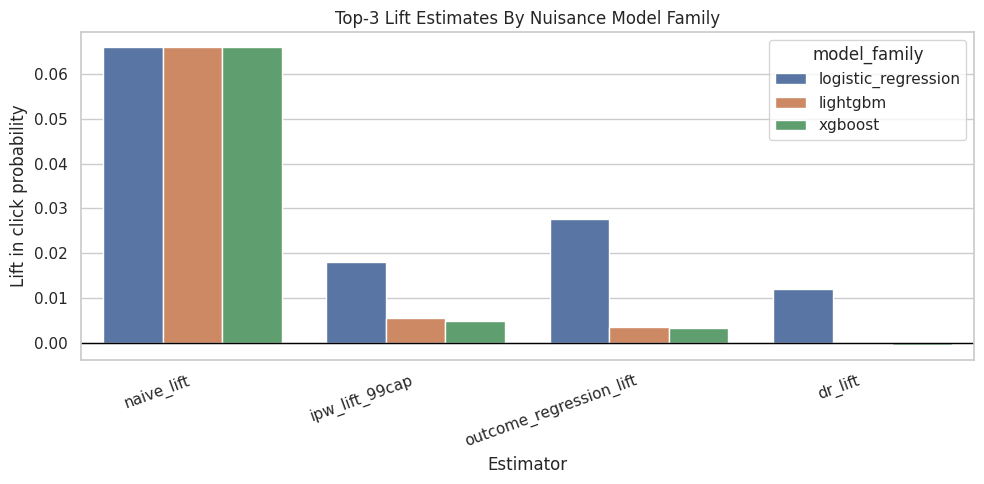

In [12]:
estimate_plot_df = model_comparison.melt(
    id_vars="model_family",
    value_vars=["naive_lift", "ipw_lift_99cap", "outcome_regression_lift", "dr_lift"],
    var_name="estimator",
    value_name="lift",
)

plt.figure(figsize=(10, 5))
sns.barplot(data=estimate_plot_df, x="estimator", y="lift", hue="model_family")
plt.axhline(0, color="black", linewidth=1)
plt.title("Top-3 Lift Estimates By Nuisance Model Family")
plt.xlabel("Estimator")
plt.ylabel("Lift in click probability")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()


The comparison table places naive, adjusted, and model-based estimates side by side. Agreement increases confidence, while large differences reveal how much adjustment changes the raw ranking-position story.


#### Plot Nuisance Model Metrics

This cell compares propensity and outcome model AUC across model families. Stronger prediction alone is insufficient for better causal estimation. Weak nuisance models can make AIPW less reliable.

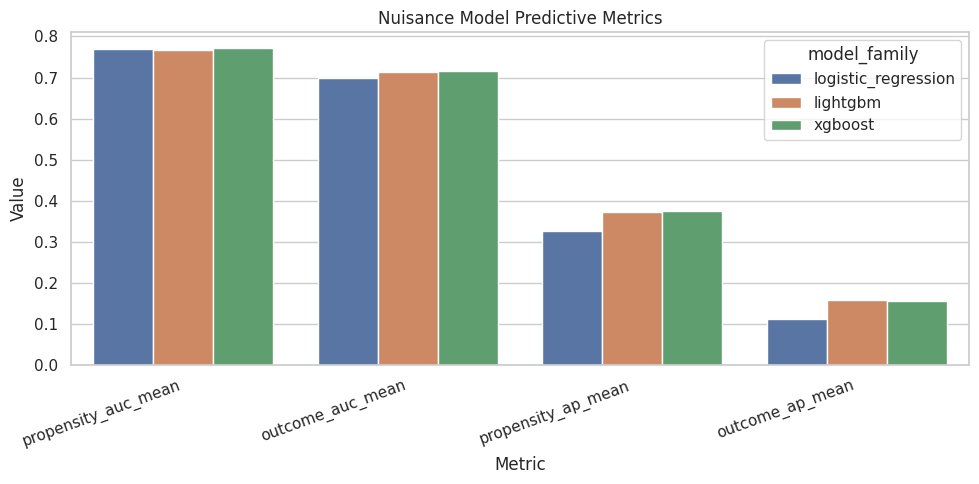

In [13]:
metric_plot_df = model_comparison.melt(
    id_vars="model_family",
    value_vars=["propensity_auc_mean", "outcome_auc_mean", "propensity_ap_mean", "outcome_ap_mean"],
    var_name="metric",
    value_name="value",
)

plt.figure(figsize=(10, 5))
sns.barplot(data=metric_plot_df, x="metric", y="value", hue="model_family")
plt.title("Nuisance Model Predictive Metrics")
plt.xlabel("Metric")
plt.ylabel("Value")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()


The nuisance-model metrics show how well the supporting prediction models perform. Weak nuisance models can make IPW, DR, and policy estimates less reliable, so these diagnostics help judge the stability of the causal workflow.


### Propensity Overlap Diagnostics

LightGBM may produce sharper propensity scores than logistic regression. Sharper scores can improve modeling, but they can also create more near-zero or near-one propensities, which makes IPW/AIPW less stable.

This section compares overlap under both nuisance model families.

#### Summarize Propensity Distributions

This cell summarizes estimated propensity scores for logistic regression and LightGBM. The percentiles show whether either model creates more extreme treatment probabilities.

In [14]:
propensity_summary = pd.concat(
    [
        logistic_scored.assign(model_family="logistic_regression"),
        lgbm_scored.assign(model_family="lightgbm"),
        xgb_scored.assign(model_family="xgboost"),
    ],
    ignore_index=True,
).groupby(["model_family", "treatment_label"])["e_hat"].describe(
    percentiles=[0.01, 0.05, 0.10, 0.50, 0.90, 0.95, 0.99]
)

propensity_summary


count   mean    std    min     1%  \
model_family        treatment_label                                          
lightgbm            rank_4_plus     91977.0000 0.0662 0.0722 0.0021 0.0076   
                    top_3            8023.0000 0.2368 0.2723 0.0034 0.0128   
logistic_regression rank_4_plus     91977.0000 0.0732 0.0680 0.0001 0.0004   
                    top_3            8023.0000 0.1607 0.0938 0.0001 0.0034   
xgboost             rank_4_plus     91977.0000 0.0664 0.0725 0.0062 0.0111   
                    top_3            8023.0000 0.2372 0.2685 0.0078 0.0147   

                                        5%    10%    50%    90%    95%    99%  \
model_family        treatment_label                                             
lightgbm            rank_4_plus     0.0132 0.0170 0.0428 0.1349 0.1945 0.3693   
                    top_3           0.0217 0.0304 0.1213 0.7087 0.9818 0.9874   
logistic_regression rank_4_plus     0.0027 0.0068 0.0511 0.1763 0.2125 0.2682   
                    top_3           0.0146 0.0297 0.1591 0.2876 0.3104 0.3365   
xgboost             rank_4_plus     0.0148 0.0181 0.0429 0.1332 0.1951 0.3720   
                    top_3           0.0230 0.0306 0.1197 0.7606 0.9413 0.9560   

                                       max  
model_family        treatment_label         
lightgbm            rank_4_plus     0.8623  
                    top_3           0.9920  
logistic_regression rank_4_plus     0.3638  
                    top_3           0.3863  
xgboost             rank_4_plus     0.8998  
                    top_3           0.9690

The propensity summaries compare overlap across model families. A model that predicts near-zero or near-one propensities too often can create unstable weights even if it has good classification performance.


#### Plot Propensity Overlap By Model Family

This cell plots propensity score distributions for treated and control rows separately for logistic regression and LightGBM. Good overlap means treated and control distributions share common support.

Text(0.5, 1.05, 'Propensity Overlap By Nuisance Model Family')

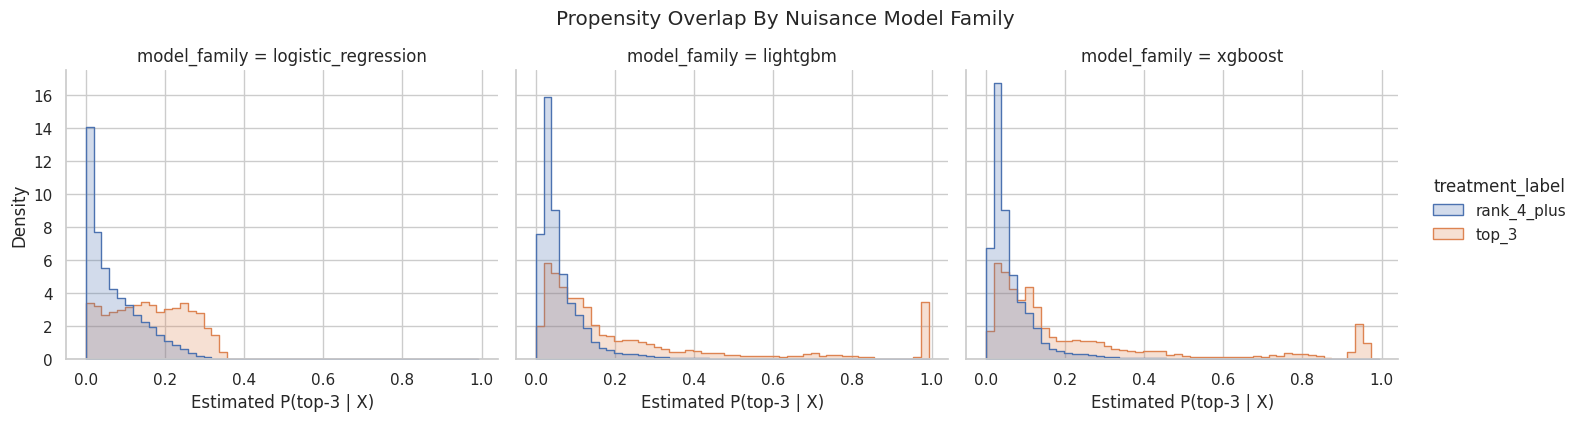

In [15]:
overlap_plot_df = pd.concat(
    [
        logistic_scored.assign(model_family="logistic_regression"),
        lgbm_scored.assign(model_family="lightgbm"),
        xgb_scored.assign(model_family="xgboost"),
    ],
    ignore_index=True,
)

g = sns.displot(
    data=overlap_plot_df,
    x="e_hat",
    hue="treatment_label",
    col="model_family",
    kind="hist",
    bins=50,
    stat="density",
    common_norm=False,
    element="step",
    height=4,
    aspect=1.2,
)
g.set_axis_labels("Estimated P(top-3 | X)", "Density")
g.fig.suptitle("Propensity Overlap By Nuisance Model Family", y=1.05)


The overlap plot shows whether treated and control rows share comparable propensity-score ranges. Good overlap supports weighting; poor overlap warns that some treated rows have no credible comparison rows, or vice versa.


### Calibration Diagnostics

AIPW uses predicted probabilities and rankings. Calibration matters because residual correction terms can behave poorly when predicted probabilities are systematically too high or too low.

These simple decile calibration checks provide a quick view of probability quality.

#### Define A Decile Calibration Helper

This cell defines a helper that bins predictions into deciles and compares average predicted probability with the observed rate. We use it for both treatment assignment and click prediction.

In [16]:
# Define a decile calibration helper.
def calibration_table(data, prediction_col, actual_col, n_bins=10):
    """
    Create a calibration table for predicted probabilities.
    
    Idea
    ----
    The table compares average predictions with observed outcomes across bins so nuisance-model reliability can be checked before causal estimates are trusted.
    
    Parameters
    ----------
    data : object
        Input analysis table for the current project step.
    prediction_col : object
        Project-specific input named `prediction_col` used by this helper.
    actual_col : object
        Project-specific input named `actual_col` used by this helper.
    n_bins : object
        Number of bins used for calibration summaries.
    
    Returns
    -------
    pandas.DataFrame
        Binned calibration summary with predicted and observed rates.
    """
    work = data[[prediction_col, actual_col]].copy()
    work["bin"] = pd.qcut(
        work[prediction_col].rank(method="first"),
        q=n_bins,
        labels=False,
    )
    return (
        work.groupby("bin", observed=True)
        .agg(
            rows=(actual_col, "size"),
            mean_prediction=(prediction_col, "mean"),
            observed_rate=(actual_col, "mean"),
        )
        .reset_index()
    )


The calibration plots check whether predicted probabilities match observed frequencies. Good calibration is especially important for propensity-based estimators because weights depend directly on probability scale.


#### Plot Propensity Calibration

This cell compares predicted treatment probability with observed top-3 rate by prediction decile. Points near the diagonal indicate better calibration. Large deviations suggest the propensity model's probabilities may need calibration.

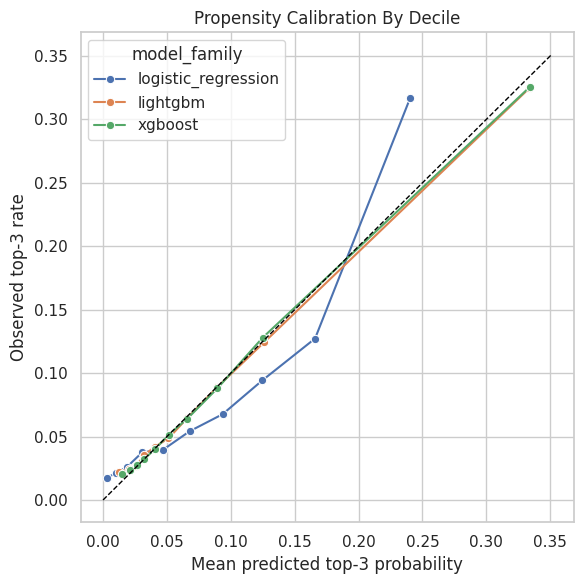

In [17]:
prop_calibration = pd.concat(
    [
        calibration_table(logistic_scored, "e_hat", "treatment").assign(model_family="logistic_regression"),
        calibration_table(lgbm_scored, "e_hat", "treatment").assign(model_family="lightgbm"),
        calibration_table(xgb_scored, "e_hat", "treatment").assign(model_family="xgboost"),
    ],
    ignore_index=True,
)

plt.figure(figsize=(6, 6))
sns.lineplot(data=prop_calibration, x="mean_prediction", y="observed_rate", hue="model_family", marker="o")
lims = [0, prop_calibration[["mean_prediction", "observed_rate"]].to_numpy().max() * 1.05]
plt.plot(lims, lims, color="black", linestyle="--", linewidth=1)
plt.title("Propensity Calibration By Decile")
plt.xlabel("Mean predicted top-3 probability")
plt.ylabel("Observed top-3 rate")
plt.tight_layout()


The calibration plots check whether predicted probabilities match observed frequencies. Good calibration is especially important for propensity-based estimators because weights depend directly on probability scale. The practical implication is that poor overlap or extreme propensity scores would make the adjusted estimate depend on a narrow slice of comparable observations.


#### Plot Outcome Calibration

This cell compares predicted click probability with observed click rate by decile. Because clicks are rare, small absolute calibration errors can still matter. Better outcome calibration can make the outcome-regression and doubly robust terms more reliable.

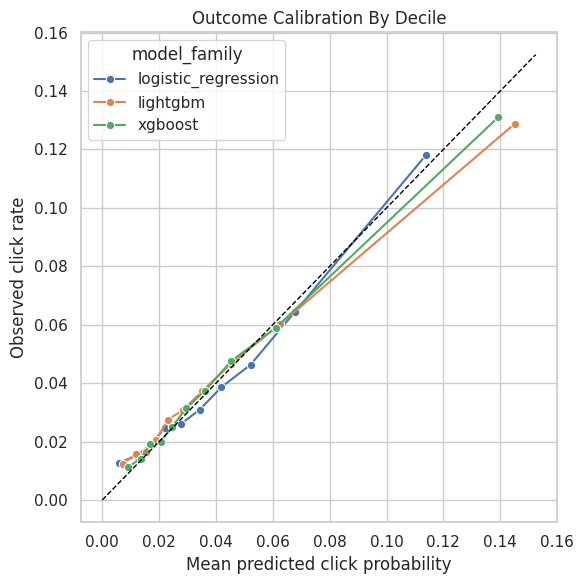

In [18]:
outcome_calibration = pd.concat(
    [
        calibration_table(logistic_scored, "y_hat_observed", "outcome").assign(model_family="logistic_regression"),
        calibration_table(lgbm_scored, "y_hat_observed", "outcome").assign(model_family="lightgbm"),
        calibration_table(xgb_scored, "y_hat_observed", "outcome").assign(model_family="xgboost"),
    ],
    ignore_index=True,
)

plt.figure(figsize=(6, 6))
sns.lineplot(data=outcome_calibration, x="mean_prediction", y="observed_rate", hue="model_family", marker="o")
lims = [0, outcome_calibration[["mean_prediction", "observed_rate"]].to_numpy().max() * 1.05]
plt.plot(lims, lims, color="black", linestyle="--", linewidth=1)
plt.title("Outcome Calibration By Decile")
plt.xlabel("Mean predicted click probability")
plt.ylabel("Observed click rate")
plt.tight_layout()


The calibration plots check whether predicted probabilities match observed frequencies. Good calibration is especially important for propensity-based estimators because weights depend directly on probability scale. The practical implication is that poor overlap or extreme propensity scores would make the adjusted estimate depend on a narrow slice of comparable observations.


### Tree Model Feature Importance

Tree-based feature importance summarizes which observed covariates LightGBM and XGBoost used most in their nuisance predictions. It describes model behavior, with causal interpretation handled by the estimand and identification design.

#### Fit Full-Sample Tree Models For Interpretation

This cell fits LightGBM and XGBoost propensity and outcome models on the full modeling sample only for feature-importance diagnostics. These full-sample models support interpretation after the cross-fitted causal estimate above.

In [19]:
full_lgbm_propensity = make_lgbm_pipeline(numeric_features, categorical_features)
full_lgbm_propensity.fit(model_df[propensity_features], model_df["treatment"])

full_lgbm_outcome = make_lgbm_pipeline(outcome_numeric_features, categorical_features)
full_lgbm_outcome.fit(model_df[outcome_features], model_df["outcome"])

full_xgb_propensity = make_xgb_pipeline(numeric_features, categorical_features)
full_xgb_propensity.fit(model_df[propensity_features], model_df["treatment"])

full_xgb_outcome = make_xgb_pipeline(outcome_numeric_features, categorical_features)
full_xgb_outcome.fit(model_df[outcome_features], model_df["outcome"])

"fitted"


'fitted'

The feature-importance output is interpretability support for the boosted-tree nuisance models. It helps explain which covariates drive treatment assignment or outcome prediction, without treating importance as a causal effect.


#### Extract Tree Model Feature Importances

This cell extracts feature names after preprocessing and joins them with tree-model feature importances. One-hot encoded categories appear as transformed feature names, which is expected after preprocessing. We compare LightGBM and XGBoost importances for both propensity and outcome nuisance models.

In [20]:
# Extract tree model feature importances.
def get_tree_importance(pipeline, model_family, nuisance_model):
    """
    Extract feature importance from a fitted tree-based nuisance pipeline.
    
    Idea
    ----
    This helper maps model importances back to readable feature names so the ranking project can audit which variables drive treatment or outcome prediction.
    
    Parameters
    ----------
    pipeline : object
        Project-specific input named `pipeline` used by this helper.
    model_family : object
        Label identifying the nuisance-model family.
    nuisance_model : object
        Project-specific input named `nuisance_model` used by this helper.
    
    Returns
    -------
    pandas.DataFrame
        Feature-importance table sorted by importance.
    """
    preprocessor = pipeline.named_steps["preprocess"]
    model = pipeline.named_steps["model"]
    feature_names = preprocessor.get_feature_names_out()
    return (
        pd.DataFrame(
            {
                "feature": feature_names,
                "importance": model.feature_importances_,
                "model_family": model_family,
                "nuisance_model": nuisance_model,
            }
        )
        .sort_values("importance", ascending=False)
        .reset_index(drop=True)
    )


importance_tables = [
    get_tree_importance(full_lgbm_propensity, "lightgbm", "propensity"),
    get_tree_importance(full_lgbm_outcome, "lightgbm", "outcome"),
    get_tree_importance(full_xgb_propensity, "xgboost", "propensity"),
    get_tree_importance(full_xgb_outcome, "xgboost", "outcome"),
]

tree_importance = pd.concat(importance_tables, ignore_index=True)

tree_importance.groupby(["model_family", "nuisance_model"]).head(10)


,feature,importance,model_family,nuisance_model
0,num__candidate_set_size,1154.0000,lightgbm,propensity
1,num__history_len,990.0000,lightgbm,propensity
2,num__log_item_exposures,955.0000,lightgbm,propensity
3,num__abstract_length,677.0000,lightgbm,propensity
4,num__hour,591.0000,lightgbm,propensity
5,num__title_length,419.0000,lightgbm,propensity
6,num__day_of_week,245.0000,lightgbm,propensity
7,cat__category_news,64.0000,lightgbm,propensity
8,cat__subcategory_basketball_nba,33.0000,lightgbm,propensity
9,cat__subcategory_celebrity,31.0000,lightgbm,propensity


The feature-importance output is interpretability support for the boosted-tree nuisance models. It helps explain which covariates drive treatment assignment or outcome prediction, without treating importance as a causal effect.


#### Plot Top Tree Model Features

This cell plots the most-used features for LightGBM and XGBoost nuisance models. These plots help explain what the ML models learned, and they should be interpreted as model-behavior summaries.

Text(0.5, 1.03, 'Top Tree Nuisance Model Features')

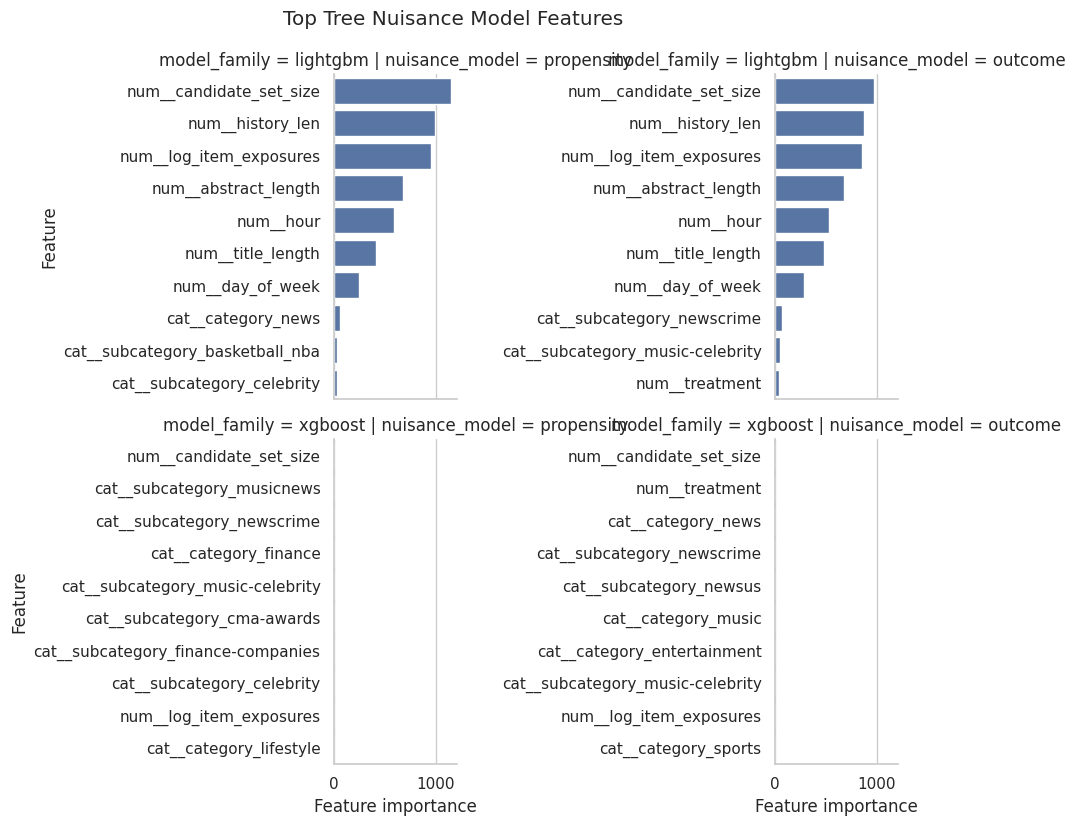

In [21]:
importance_plot_df = (
    tree_importance.groupby(["model_family", "nuisance_model"], group_keys=False)
    .head(10)
    .reset_index(drop=True)
)

g = sns.catplot(
    data=importance_plot_df,
    x="importance",
    y="feature",
    row="model_family",
    col="nuisance_model",
    kind="bar",
    sharey=False,
    height=4,
    aspect=1.15,
)
g.set_axis_labels("Feature importance", "Feature")
g.fig.suptitle("Top Tree Nuisance Model Features", y=1.03)


The feature-importance output is interpretability support for the boosted-tree nuisance models. It helps explain which covariates drive treatment assignment or outcome prediction, without treating importance as a causal effect.


### Boosted-Tree Clipping Sensitivity

Because boosted trees can produce sharper probabilities, we should check whether their AIPW estimates are sensitive to propensity clipping. Stable estimates across clipping thresholds are reassuring.

#### Recompute Boosted-Tree AIPW With Different Clipping Thresholds

This cell recomputes LightGBM and XGBoost AIPW estimates using several values of `epsilon`. Larger `epsilon` means stronger clipping away from 0 and 1. If either estimate changes sharply, that model may be relying on low-overlap observations.

In [22]:
clipping_rows = []
for model_family, scored in [("lightgbm", lgbm_scored), ("xgboost", xgb_scored)]:
    for eps in [0.001, 0.005, 0.01, 0.02, 0.05]:
        e = scored["e_hat"].clip(eps, 1 - eps).to_numpy()
        t_np = scored["treatment"].to_numpy()
        y_np = scored["outcome"].to_numpy()
        mu1 = scored["mu1_hat"].to_numpy()
        mu0 = scored["mu0_hat"].to_numpy()

        scores = (mu1 - mu0) + t_np * (y_np - mu1) / e - (1 - t_np) * (y_np - mu0) / (1 - e)
        se = scores.std(ddof=1) / np.sqrt(len(scores))
        clipping_rows.append(
            {
                "model_family": model_family,
                "epsilon": eps,
                "dr_lift": scores.mean(),
                "standard_error": se,
                "ci_95_lower": scores.mean() - 1.96 * se,
                "ci_95_upper": scores.mean() + 1.96 * se,
            }
        )

boosted_clipping_sensitivity = pd.DataFrame(clipping_rows)
boosted_clipping_sensitivity


,model_family,epsilon,dr_lift,standard_error,ci_95_lower,ci_95_upper
0,lightgbm,0.0010,-0.0002,0.0028,-0.0058,0.0053
1,lightgbm,0.0050,-0.0002,0.0028,-0.0057,0.0054
2,lightgbm,0.0100,0.0000,0.0028,-0.0055,0.0056
3,lightgbm,0.0200,0.0002,0.0026,-0.0050,0.0054
4,lightgbm,0.0500,0.0006,0.0020,-0.0034,0.0045
5,xgboost,0.0010,-0.0005,0.0027,-0.0057,0.0047
6,xgboost,0.0050,-0.0005,0.0027,-0.0057,0.0047
7,xgboost,0.0100,-0.0005,0.0027,-0.0057,0.0047
8,xgboost,0.0200,-0.0005,0.0025,-0.0054,0.0044
9,xgboost,0.0500,0.0006,0.0020,-0.0033,0.0044


The clipping sensitivity output shows how much the estimate depends on trimming extreme weights or probabilities. Stable estimates across clipping thresholds are more reassuring than estimates that move sharply.


#### Plot Boosted-Tree Clipping Sensitivity

This cell plots LightGBM and XGBoost DR estimates under different clipping thresholds. If the lines are relatively flat, the estimates are relatively insensitive to the clipping choice. Large movement would be a caution flag.

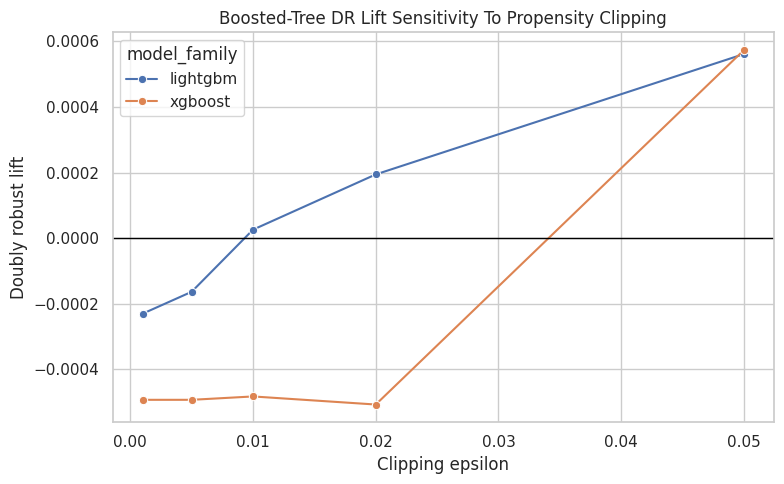

In [23]:
plt.figure(figsize=(8, 5))
sns.lineplot(data=boosted_clipping_sensitivity, x="epsilon", y="dr_lift", hue="model_family", marker="o")
plt.axhline(0, color="black", linewidth=1)
plt.title("Boosted-Tree DR Lift Sensitivity To Propensity Clipping")
plt.xlabel("Clipping epsilon")
plt.ylabel("Doubly robust lift")
plt.tight_layout()


The clipping sensitivity output shows how much the estimate depends on trimming extreme weights or probabilities. Stable estimates across clipping thresholds are more reassuring than estimates that move sharply.


## Interpretation Checklist

Use this notebook to answer:

1. Do LightGBM or XGBoost improve propensity or outcome prediction compared with logistic regression?
2. Do the boosted-tree doubly robust estimates agree directionally with the logistic estimate?
3. Do LightGBM or XGBoost create more extreme propensity scores?
4. Are the propensity and outcome probabilities reasonably calibrated by decile?
5. Are the boosted-tree estimates stable under propensity clipping?

Taken together, these checks show how much the causal estimate depends on the nuisance-model family. Directional agreement across logistic, LightGBM, and XGBoost versions supports a more stable estimate, while disagreements mark places where the conclusion depends on modeling choices.